<a href="https://colab.research.google.com/github/equinox-1092/Notes_Power_Bi/blob/master/SESI%C3%93N_5_intermedio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

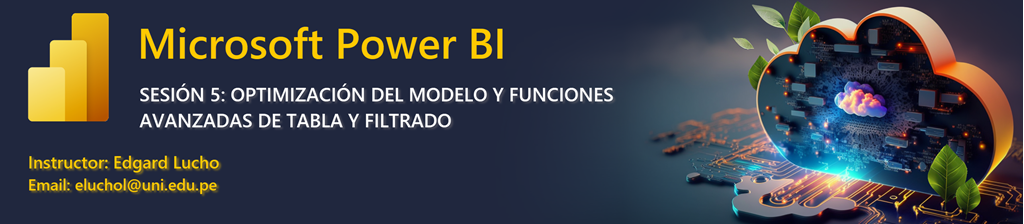

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">SESIÓN 5: OPTIMIZACIÓN DEL MODELO Y FUNCIONES AVANZADAS DE TABLA Y FILTRADO</font>**

</td>
</tr>
</table>

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Costo Promedio Ponderado</font>**

</td>
</tr>
</table>

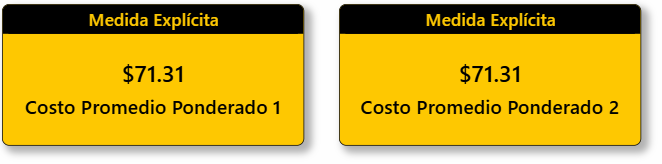



```
Costo Promedio Ponderado 1 =
DIVIDE
(
    SUMX
    (
        FactSales,
        FactSales[UnitCost] * (FactSales[SalesQuantity] - FactSales[ReturnQuantity])
    ),
    SUMX
    (
        FactSales,
        (FactSales[SalesQuantity] - FactSales[ReturnQuantity])
    ),
    0
)
```





```
Costo Promedio Ponderado 2 =
AVERAGEX
(
    VALUES(DimProduct[ProductKey]),
    SUMX
    (
        FactSales,
        FactSales[UnitCost] * (FactSales[SalesQuantity]-FactSales[ReturnQuantity])
    )
    /
    SUMX(FactSales,FactSales[SalesQuantity]-FactSales[ReturnQuantity])
)
```



<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">ALL</font>**

</td>
</tr>
</table>

La función ALL en DAX es una herramienta poderosa diseñada para controlar el contexto de filtros en los cálculos, permitiendo a los analistas de datos obtener resultados más precisos y significativos en sus métricas.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Sintaxis</font>**

</td>
</tr>
</table>



```
ALL(Tabla | <Columna> | <Conjunto de Columnas>)
```



>* **Tabla**: Nombre de la tabla de la que se eliminarán los filtros.
>* **<Columna>**: Nombre de la columna de la que se eliminarán los filtros.
>* **<Conjunto de Columnas>**: Puedes pasar un conjunto de columnas para eliminar los filtros de todas ellas.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Finalidad</font>**

</td>
</tr>
</table>

>* **Contexto de Filtros**
    * En DAX, cada cálculo se basa en un contexto de filtro que puede ser modificado por la selección de datos en un informe. La función ALL permite ignorar ese contexto de filtro, facilitando la creación de medidas más robustas.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Ejemplos</font>**

</td>
</tr>
</table>



```
Ventas SUMX =
SUMX
(
    FactSales,
    FactSales[SalesQuantity] * FactSales[UnitPrice] - FactSales[DiscountAmount]
)
```





```
Ventas SUMX ALL =
SUMX
(
    ALL(FactSales),
    FactSales[SalesQuantity]*FactSales[UnitPrice] - FactSales[DiscountAmount]
)
```





```
% de Participación 1 = DIVIDE([Ventas SUMX], [Ventas SUMX ALL], 0)
```





```
% de Participación 2 =
DIVIDE
(
    SUMX
    (
        FactSales,
        FactSales[SalesQuantity] * FactSales[UnitPrice] - FactSales[DiscountAmount]
    ),
    SUMX
    (
        ALL(FactSales),
        FactSales[SalesQuantity] * FactSales[UnitPrice] - FactSales[DiscountAmount]
    ),
    0
)
```





```
% de Participación 3 =
DIVIDE
(
    SUMX
    (
        FactSales,
        FactSales[SalesQuantity] * FactSales[UnitPrice] - FactSales[DiscountAmount]
    ),
    CALCULATE
    (
        SUMX
        (
            FactSales,
            FactSales[SalesQuantity] * FactSales[UnitPrice] - FactSales[DiscountAmount]
        ),
        ALL(FactSales)
    ),
    0
)
```



<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">ALLSELECTED</font>**

</td>
</tr>
</table>

La función **ALLSELECTED** en DAX es una herramienta importante para gestionar el contexto de filtros en tus análisis y medidas.

Su principal uso es devolver valores de una tabla o columna mientras mantiene el contexto de los filtros que se han aplicado en visualizaciones, pero mediante el uso de selecciones múltiples.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Sintaxis</font>**

</td>
</tr>
</table>



```
ALLSELECTED(Tabla | <Columna>)
```



>* **Tabla**: Nombre de la tabla para la que deseas obtener los datos.
>* **<Columna>**: Nombre de la columna de la cual deseas obtener los valores.


<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Funcionalidad</font>**

</td>
</tr>
</table>

>* **ALLSELECTED** permite obtener un conjunto de datos que considera los filtros del contexto actual, incluidos los filtros del reporte que no estén directamente aplicados en la visualización en la que se encuentra la medida.
>* Esto es útil cuando quieres calcular medidas que consideren los filtros aplicados por el usuario, pero que también sean más amplios que el conjunto específico de filtros de la visualización.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Ejemplo</font>**

</td>
</tr>
</table>



```
Ventas SUMX ALLSELECTED =
SUMX
(
    ALLSELECTED(FactSales),
    FactSales[SalesQuantity] * FactSales[UnitPrice] - FactSales[DiscountAmount]
)
```



<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">ALLEXCEPT</font>**

</td>
</tr>
</table>

La función ALLEXCEPT en DAX es útil para eliminar todos los filtros de una tabla, excepto aquellos que se especifican para determinadas columnas.

Esto permite a los analistas realizar cálculos que conservan el contexto de ciertas dimensiones mientras ignoran otros filtros aplicados.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Sintaxis</font>**

</td>
</tr>
</table>



```
ALLEXCEPT(Tabla, <Columna1>, <Columna2>, <Columna3>, ...)
```



>* Tabla:  La tabla de la que se eliminarán los filtros.
>* **< Columna1>, < Columna2>, < Columna3>, ...**: Una o más columnas para las que se conservarán los filtros.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Funcionalidad</font>**

</td>
</tr>
</table>

En DAX, el contexto de filtros determina qué datos se incluyen en los cálculos.

ALLEXCEPT permite controlar este contexto de manera más específica, conservando las interacciones de ciertas dimensiones mientras se ignoran otras.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Ejemplo</font>**

</td>
</tr>
</table>



```
Mis 5 Mejores Productos =
TOPN
(
    5,
    DimProduct,
    CALCULATE
    (
       SUMX
        (
            FactSales,
            FactSales[SalesQuantity] * FactSales[UnitPrice] - FactSales[DiscountAmount]
        )
    ),
    DESC
)
```





```
Mis 5 Mejores Tiendas =
TOPN
(
    5,
    DimStore,
    CALCULATE
    (
       SUMX
        (
            FactSales,
            FactSales[SalesQuantity] * FactSales[UnitPrice] - FactSales[DiscountAmount]
        )
    ),
    DESC
)
```





```
Mis 5 Mejores Tiendas 2 =
CALCULATETABLE
(
    DimStore,
    TOPN
    (
        5,
        DimStore,
        CALCULATE
        (
            SUMX
            (
                FactSales,
                FactSales[SalesQuantity] * FactSales[UnitPrice] - FactSales[DiscountAmount]
            )
        ),
        DESC
    )
)
```

